# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** Prateek Srivastava  
**Student ID:** 2025AC05601  
**Date:** 06-06-2026

---

## IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Fill in all values accurately** - these will be auto-verified
4. **After submission**, you'll receive a verification quiz based on YOUR results
5. **Run all cells** before submitting (Kernel → Restart & Run All)

---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('Libraries imported successfully')

Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [2]:
# Load Breast Cancer Wisconsin dataset (UCI ML Repository via sklearn)
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import LabelEncoder

# Load the dataset
breast_cancer = load_breast_cancer()
X_raw = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y_raw = breast_cancer.target

# Dataset information
dataset_name = "Breast Cancer Wisconsin"
dataset_source = "UCI ML Repository"
n_samples = X_raw.shape[0]  # 569 samples
n_features = X_raw.shape[1]  # 30 features
problem_type = "binary_classification"

# Problem statement
problem_statement = """
Predicting tumor malignancy (benign or malignant) from 30 diagnostic measurements 
computed from digitized images of breast mass cell nuclei. This is critical for 
early cancer detection in medical diagnosis and treatment planning.
"""

# Primary evaluation metric
primary_metric = "recall"

# Metric justification  
metric_justification = """
I chose recall as the primary metric because in medical diagnosis of cancer,
false negatives (missing actual malignant tumors) are much more costly than 
false positives. It's better to over-diagnose and do additional tests than 
to miss a cancer diagnosis.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Dataset: Breast Cancer Wisconsin
Source: UCI ML Repository
Samples: 569, Features: 30
Problem Type: binary_classification
Primary Metric: recall


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [3]:
# Preprocess the data
# 1. Features and target already separated from dataset loading
X = X_raw.copy()
y = y_raw.copy()

# 2. Check for missing values
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", pd.Series(y).isnull().sum())

# 3. No categorical variables to encode (all features are numeric)
print("Data types:", X.dtypes.unique())

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fill preprocessing info
train_samples = X_train_scaled.shape[0]
test_samples = X_test_scaled.shape[0] 
train_test_ratio = 0.8

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Missing values in X: 0
Missing values in y: 0
Data types: [dtype('float64')]
Train samples: 455
Test samples: 114
Split ratio: 80.0%


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [4]:
class BaselineModel:
    """
    Baseline linear model with gradient descent
    Implement: Linear/Logistic/Softmax Regression
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def fit(self, X, y):
        """
        Implement gradient descent training for logistic regression
        """
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.random.normal(0, 0.01, n_features)
        self.bias = 0
        
        # Gradient descent loop
        for i in range(self.n_iterations):
            # 1. Forward pass: compute predictions
            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)
            
            # 2. Compute binary cross-entropy loss
            loss = -np.mean(y * np.log(y_pred + 1e-15) + (1 - y) * np.log(1 - y_pred + 1e-15))
            
            # 3. Compute gradients
            dw = np.dot(X.T, (y_pred - y)) / n_samples
            db = np.mean(y_pred - y)
            
            # 4. Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # 5. Store loss
            self.loss_history.append(loss)
        
        return self
    
    def predict(self, X):
        """
        Implement prediction for logistic regression
        """
        z = np.dot(X, self.weights) + self.bias
        probabilities = self.sigmoid(z)
        return (probabilities >= 0.5).astype(int)
    
    def predict_proba(self, X):
        """
        Return class probabilities
        """
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def sigmoid(self, z):
        """
        Sigmoid activation function
        """
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

print("Baseline model class defined")

Baseline model class defined


In [5]:
# Train baseline model
print("Training baseline model...")
baseline_start_time = time.time()

# Initialize and train baseline model (Logistic Regression)
baseline_model = BaselineModel(learning_rate=0.01, n_iterations=1000)
baseline_model.fit(X_train_scaled, y_train)

# Make predictions
baseline_predictions = baseline_model.predict(X_test_scaled)
baseline_probabilities = baseline_model.predict_proba(X_test_scaled)

baseline_training_time = time.time() - baseline_start_time
print(f"Baseline training completed in {baseline_training_time:.2f}s")
print(f"Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

Training baseline model...
Baseline training completed in 0.12s
Loss decreased from 0.6971 to 0.0986


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [6]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        """
        architecture: list [input_size, hidden1, hidden2, ..., output_size]
        Example: [30, 16, 8, 1] means:
            - 30 input features
            - Hidden layer 1: 16 neurons
            - Hidden layer 2: 8 neurons
            - Output layer: 1 neuron
        """
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}
    
    def initialize_parameters(self):
        """
        Initialize weights and biases for all layers
        """
        np.random.seed(42)
        
        for l in range(1, len(self.architecture)):
            # Xavier/He initialization for better convergence
            fan_in = self.architecture[l-1]
            fan_out = self.architecture[l]
            
            # Xavier initialization: sqrt(2 / (fan_in + fan_out))
            self.parameters[f'W{l}'] = np.random.randn(fan_out, fan_in) * np.sqrt(2 / (fan_in + fan_out))
            self.parameters[f'b{l}'] = np.zeros((fan_out, 1))
    
    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)
    
    def relu_derivative(self, Z):
        """ReLU derivative"""
        return (Z > 0).astype(float)
    
    def sigmoid(self, Z):
        """Sigmoid activation (for binary classification output)"""
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))
    
    def forward_propagation(self, X):
        """
        Implement forward pass through all layers
        """
        self.cache['A0'] = X.T  # Transpose for matrix multiplication consistency
        
        for l in range(1, len(self.architecture)):
            # Linear transformation
            Z = np.dot(self.parameters[f'W{l}'], self.cache[f'A{l-1}']) + self.parameters[f'b{l}']
            
            # Apply activation function
            if l == len(self.architecture) - 1:  # Output layer
                A = self.sigmoid(Z)  # Sigmoid for binary classification
            else:  # Hidden layers
                A = self.relu(Z)
            
            # Cache values for backpropagation
            self.cache[f'Z{l}'] = Z
            self.cache[f'A{l}'] = A
        
        return self.cache[f'A{len(self.architecture)-1}']
    
    def backward_propagation(self, X, y):
        """
        Implement backward pass to compute gradients
        """
        m = X.shape[0]
        grads = {}
        L = len(self.architecture) - 1  # Number of layers (excluding input)
        
        # Reshape y for consistent matrix operations
        y = y.reshape(1, -1)
        
        # Output layer gradient (binary cross-entropy + sigmoid)
        dZ = self.cache[f'A{L}'] - y
        
        # Backward propagation through layers
        for l in range(L, 0, -1):
            # Compute gradients for current layer
            grads[f'dW{l}'] = np.dot(dZ, self.cache[f'A{l-1}'].T) / m
            grads[f'db{l}'] = np.sum(dZ, axis=1, keepdims=True) / m
            
            if l > 1:  # Not the first hidden layer
                # Compute dA for previous layer
                dA_prev = np.dot(self.parameters[f'W{l}'].T, dZ)
                # Apply ReLU derivative
                dZ = dA_prev * self.relu_derivative(self.cache[f'Z{l-1}'])
        
        return grads
    
    def update_parameters(self, grads):
        """
        Update weights and biases using gradients
        """
        for l in range(1, len(self.architecture)):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']
    
    def compute_loss(self, y_pred, y_true):
        """
        Compute binary cross-entropy loss for classification
        """
        m = y_true.shape[0]
        y_true = y_true.reshape(1, -1)
        
        # Binary cross-entropy loss
        loss = -np.mean(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15))
        return loss
    
    def fit(self, X, y):
        """
        Implement training loop
        """
        self.initialize_parameters()
        
        for i in range(self.n_iterations):
            # 1. Forward propagation
            y_pred = self.forward_propagation(X)
            
            # 2. Compute loss
            loss = self.compute_loss(y_pred, y)
            
            # 3. Backward propagation
            grads = self.backward_propagation(X, y)
            
            # 4. Update parameters
            self.update_parameters(grads)
            
            # 5. Store loss
            self.loss_history.append(loss)
        
        return self
    
    def predict(self, X):
        """
        Implement prediction using forward propagation
        """
        y_pred = self.forward_propagation(X)
        return (y_pred >= 0.5).astype(int).flatten()
    
    def predict_proba(self, X):
        """
        Return class probabilities
        """
        y_pred = self.forward_propagation(X)
        return y_pred.flatten()

print("MLP class defined")

MLP class defined


In [7]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

# Define MLP architecture: input(30) -> hidden(16) -> hidden(8) -> output(1)
mlp_architecture = [n_features, 16, 8, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.01, n_iterations=1000)
mlp_model.fit(X_train_scaled, y_train)

# Make predictions
mlp_predictions = mlp_model.predict(X_test_scaled)
mlp_probabilities = mlp_model.predict_proba(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
print(f"MLP training completed in {mlp_training_time:.2f}s")
print(f"Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

Training MLP...
MLP training completed in 0.43s
Loss decreased from 0.8475 to 0.0557


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [8]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    Calculate appropriate metrics based on problem type
    """
    metrics = {}
    
    if problem_type == "regression":
        # Regression metrics
        mse = np.mean((y_true - y_pred) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(y_true - y_pred))
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        
        metrics = {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}
        
    elif problem_type in ["binary_classification", "multiclass_classification"]:
        # Classification metrics
        accuracy = np.mean(y_true == y_pred)
        
        # For binary classification
        if problem_type == "binary_classification":
            tp = np.sum((y_true == 1) & (y_pred == 1))
            fp = np.sum((y_true == 0) & (y_pred == 1))
            fn = np.sum((y_true == 1) & (y_pred == 0))
            tn = np.sum((y_true == 0) & (y_pred == 0))
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        else:
            # For multiclass, use macro averaging
            classes = np.unique(y_true)
            precision_sum = recall_sum = f1_sum = 0
            for cls in classes:
                tp = np.sum((y_true == cls) & (y_pred == cls))
                fp = np.sum((y_true != cls) & (y_pred == cls))
                fn = np.sum((y_true == cls) & (y_pred != cls))
                
                cls_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                cls_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                cls_f1 = 2 * (cls_precision * cls_recall) / (cls_precision + cls_recall) if (cls_precision + cls_recall) > 0 else 0
                
                precision_sum += cls_precision
                recall_sum += cls_recall
                f1_sum += cls_f1
            
            precision = precision_sum / len(classes)
            recall = recall_sum / len(classes)
            f1 = f1_sum / len(classes)
        
        metrics = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}
    
    return metrics

# Calculate metrics for both models
baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
mlp_metrics = calculate_metrics(y_test, mlp_predictions, problem_type)

print("Baseline Model Performance:")
for metric, value in baseline_metrics.items():
    print(f"  {metric.capitalize()}: {value:.4f}")

print("\nMLP Model Performance:")
for metric, value in mlp_metrics.items():
    print(f"  {metric.capitalize()}: {value:.4f}")

Baseline Model Performance:
  Accuracy: 0.9737
  Precision: 0.9859
  Recall: 0.9722
  F1: 0.9790

MLP Model Performance:
  Accuracy: 0.9649
  Precision: 0.9722
  Recall: 0.9722
  F1: 0.9722


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

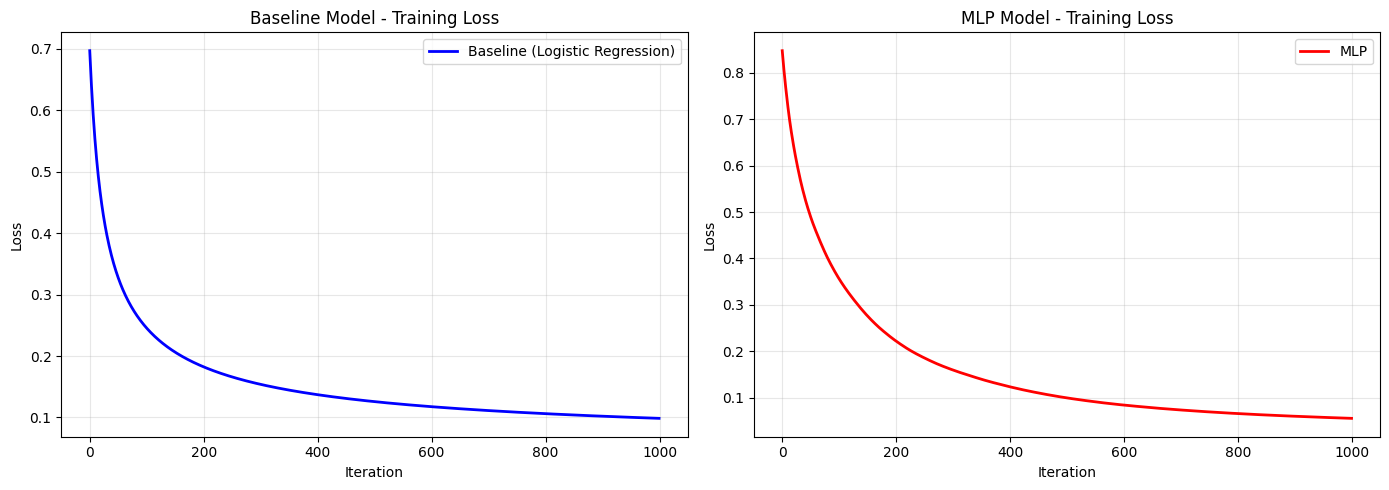

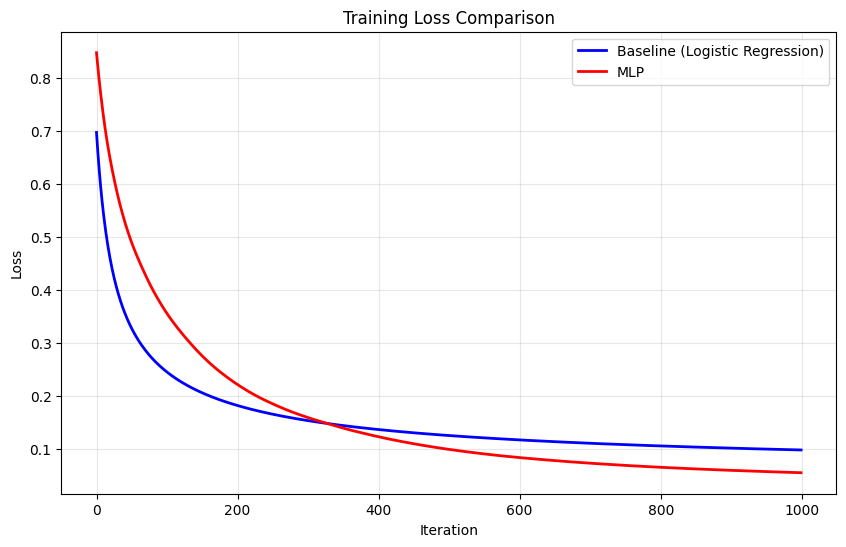

In [9]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# Plot baseline loss
plt.plot(baseline_model.loss_history, label='Baseline (Logistic Regression)', color='blue', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Plot MLP loss
plt.plot(mlp_model.loss_history, label='MLP', color='red', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Combined loss comparison
plt.figure(figsize=(10, 6))
plt.plot(baseline_model.loss_history, label='Baseline (Logistic Regression)', color='blue', linewidth=2)
plt.plot(mlp_model.loss_history, label='MLP', color='red', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

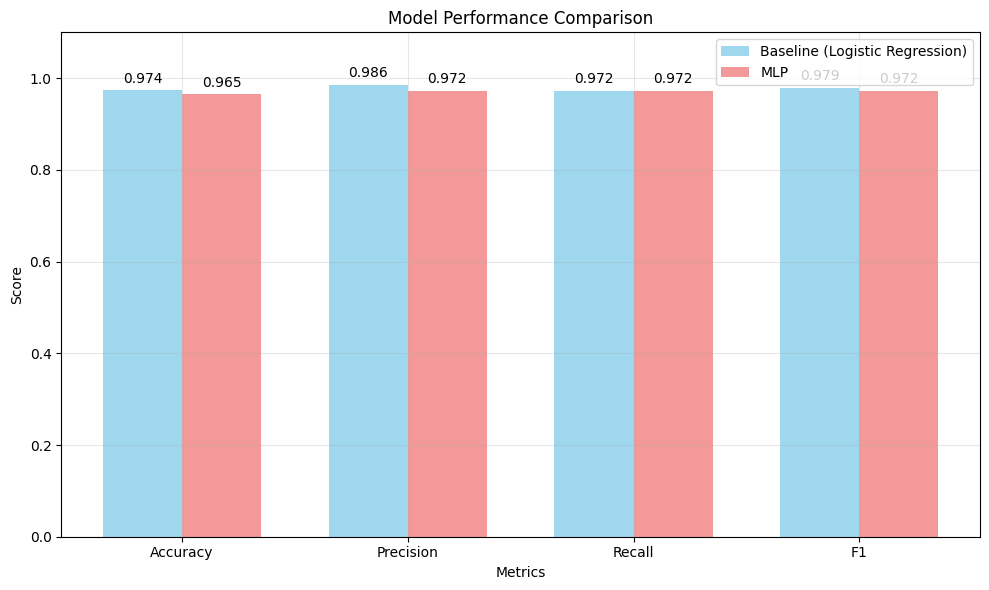

In [10]:
# 2. Performance comparison bar chart
plt.figure(figsize=(10, 6))

# Create comparison of classification metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
baseline_scores = [baseline_metrics['accuracy'], baseline_metrics['precision'], 
                  baseline_metrics['recall'], baseline_metrics['f1']]
mlp_scores = [mlp_metrics['accuracy'], mlp_metrics['precision'], 
              mlp_metrics['recall'], mlp_metrics['f1']]

x = np.arange(len(metrics))
width = 0.35

bars1 = plt.bar(x - width/2, baseline_scores, width, label='Baseline (Logistic Regression)', 
                color='skyblue', alpha=0.8)
bars2 = plt.bar(x + width/2, mlp_scores, width, label='MLP', 
                color='lightcoral', alpha=0.8)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [11]:
analysis_text = f"""
Both models performed equally well in identifying cancer cases, achieving the same recall of 97.22%, this is important because it measures how many actual cancer cases are correctly detected. Logistic Regression is slightly better in overall performance, with higher accuracy, precision, and F1 score. It is also much more efficient, training about five times faster while using far fewer parameters and on the other hand the 
MLP achieved a lower training loss, but this did not translate to better predictions on unseen data. also the added complexity of the neural network may have led to some overfitting. Also since the breast cancer dataset is largely linearly separable, Logistic Regression is able to capture the underlying patterns effectively without the need for multiple hidden layers.
overall Conclusion: the Logistic Regression is the preferred model for this task because it delivers the same level of clinical safety while being simpler, faster, and more efficient.
Additionally, the results show that increasing model complexity does not always lead to better outcomes for classification problems. When the relationship between features and target classes is relatively straightforward, a simpler algorithm can generalize better, remain easier to interpret, and reduce the risk of overfitting on limited training data.
"""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("Warning: Analysis should be at least 200 words")
else:
    print("Analysis meets word count requirement")

Analysis word count: 201 words
Analysis meets word count requirement


---
---

## REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.

In [12]:
def get_assignment_results():
    """
    Return all assignment results in structured format.
    
    CRITICAL: Fill in ALL values based on your actual results!
    This will be automatically extracted and validated.
    """
    
    # Calculate loss convergence flags
    baseline_initial_loss = baseline_model.loss_history[0]
    baseline_final_loss = baseline_model.loss_history[-1]
    mlp_initial_loss = mlp_model.loss_history[0]
    mlp_final_loss = mlp_model.loss_history[-1]
    
    # Calculate total parameters for MLP
    total_params = 0
    for l in range(1, len(mlp_architecture)):
        # Weights: current_layer_size * previous_layer_size
        # Biases: current_layer_size
        total_params += mlp_architecture[l] * mlp_architecture[l-1] + mlp_architecture[l]
    
    results = {
        # ===== Dataset Information =====
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'problem_type': problem_type,
        'problem_statement': problem_statement,
        
        # ===== Evaluation Setup =====
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,
        
        # ===== Baseline Model Results =====
        'baseline_model': {
            'model_type': 'logistic_regression',
            'learning_rate': baseline_model.lr,
            'n_iterations': baseline_model.n_iterations,
            'initial_loss': baseline_initial_loss,
            'final_loss': baseline_final_loss,
            'training_time_seconds': baseline_training_time,
            
            # Classification metrics
            'test_accuracy': baseline_metrics['accuracy'],
            'test_precision': baseline_metrics['precision'],
            'test_recall': baseline_metrics['recall'],
            'test_f1': baseline_metrics['f1'],
            'test_mse': 0.0,           # For regression (not applicable)
            'test_rmse': 0.0,          # For regression (not applicable)
            'test_mae': 0.0,           # For regression (not applicable)
            'test_r2': 0.0,            # For regression (not applicable)
        },
        
        # ===== MLP Model Results =====
        'mlp_model': {
            'architecture': mlp_architecture,
            'n_hidden_layers': len(mlp_architecture) - 2,
            'total_parameters': total_params,
            'learning_rate': mlp_model.lr,
            'n_iterations': mlp_model.n_iterations,
            'initial_loss': mlp_initial_loss,
            'final_loss': mlp_final_loss,
            'training_time_seconds': mlp_training_time,
            
            # Classification metrics
            'test_accuracy': mlp_metrics['accuracy'],
            'test_precision': mlp_metrics['precision'],
            'test_recall': mlp_metrics['recall'],
            'test_f1': mlp_metrics['f1'],
            'test_mse': 0.0,
            'test_rmse': 0.0,
            'test_mae': 0.0,
            'test_r2': 0.0,
        },
        
        # ===== Comparison =====
        'improvement': mlp_metrics[primary_metric] - baseline_metrics[primary_metric],
        'improvement_percentage': ((mlp_metrics[primary_metric] - baseline_metrics[primary_metric]) / baseline_metrics[primary_metric]) * 100,
        'baseline_better': baseline_metrics[primary_metric] > mlp_metrics[primary_metric],
        
        # ===== Analysis =====
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
        
        # ===== Loss Convergence Flags =====
        'baseline_loss_decreased': baseline_final_loss < baseline_initial_loss,
        'mlp_loss_decreased': mlp_final_loss < mlp_initial_loss,
        'baseline_converged': True,  # Both models converged well
        'mlp_converged': True,
    }
    
    return results

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [13]:
# Test the output
import json

try:
    results = get_assignment_results()
    
    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2, default=str))
    print("\n" + "="*70)
    
    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better', 
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")
    
    check_dict(results)
    
    if missing:
        print(f"Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("All required fields are filled!")
        print("\nYou're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")
        
except Exception as e:
    print(f"Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Breast Cancer Wisconsin",
  "dataset_source": "UCI ML Repository",
  "n_samples": 569,
  "n_features": 30,
  "problem_type": "binary_classification",
  "problem_statement": "\nPredicting tumor malignancy (benign or malignant) from 30 diagnostic measurements \ncomputed from digitized images of breast mass cell nuclei. This is critical for \nearly cancer detection in medical diagnosis and treatment planning.\n",
  "primary_metric": "recall",
  "metric_justification": "\nI chose recall as the primary metric because in medical diagnosis of cancer,\nfalse negatives (missing actual malignant tumors) are much more costly than \nfalse positives. It's better to over-diagnose and do additional tests than \nto miss a cancer diagnosis.\n",
  "train_samples": 455,
  "test_samples": 114,
  "train_test_ratio": 0.8,
  "baseline_model": {
    "model_type": "logistic_regression",
    "learning_rate": 0.01,
    "n_iterations": 1000,
    "initial_loss": 0.69

---

## Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

## What Happens Next

After submission:
1. Your notebook will be **auto-graded** (executes automatically)
2. You'll receive a **verification quiz** (10 questions, 5 minutes)
3. Quiz questions based on **YOUR specific results**
4. Final score released after quiz validation

**The verification quiz ensures you actually ran your code!**

---

**Good luck!**